# How to deal with imbalanced datasets?

- CODE: feat: [SC] - reduce the impact of financial phrasebank imbalance [#95](https://github.com/ufdatastudio/predictions/issues/95)

---
1. ARTICLE: [Should You Use Imbalanced-Learn in 2025?](https://www.blog.trainindata.com/should-you-use-imbalanced-learn-in-2025/)
2. PAPER: [Imbalanced-learn: A Python Toolbox to Tackle the Curse of Imbalanced Datasets in Machine Learning](https://www.jmlr.org/papers/v18/16-365.html)

In [1]:
import os
import sys

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt


from sklearn.datasets import make_classification
from imblearn.over_sampling import RandomOverSampler

# Get the current working directory of the notebook
notebook_dir = os.getcwd()
# Add the parent directory to the system path
sys.path.append(os.path.join(notebook_dir, '../'))

from data_processing import DataProcessing
from data_visualizing import DataVisualizing
from feature_extraction import SpacyFeatureExtraction

## Experiment with Synthetic data

- Comes from [1]

## Step 1: Create a synthetic imbalanced dataset

In [2]:
X, y = make_classification(
n_samples=500,
n_features=2,
n_informative=2,
n_redundant=0,
n_clusters_per_class=1,
weights=[0.9, 0.1],
flip_y=0,
random_state=42
)

In [3]:
# Correct approach
synthetic_df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
synthetic_df['Label'] = y
synthetic_df

,Feature_1,Feature_2,Label
0,-0.634459,1.196683,0
1,1.059371,0.121880,0
2,-0.346128,0.670353,0
3,-4.058955,2.498408,0
4,-1.495259,2.865142,0
...,...,...,...
495,-1.450271,0.630604,0
496,2.026043,2.720493,1
497,-0.890525,0.469038,0
498,-3.293571,1.747423,0


## Step 2: Visualize the original dataset before oversampling

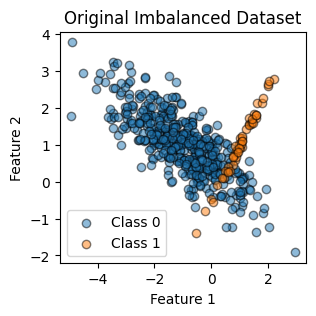

In [4]:
plt.figure(figsize=(7, 3))
plt.subplot(1, 2, 1)
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label="Class 0", alpha=0.5, edgecolor="k")
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label="Class 1", alpha=0.5, edgecolor="k")
plt.title("Original Imbalanced Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()

## Step 3: Apply RandomOverSampler to balance the dataset

In [5]:
oversample = RandomOverSampler(sampling_strategy='minority', random_state=42)
oversample

RandomOverSampler(random_state=42, sampling_strategy='minority')

## Step 4: Visualize the dataset after oversampling

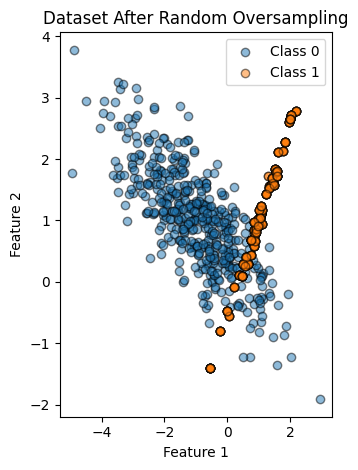

In [6]:
X_over, y_over = oversample.fit_resample(X, y)

plt.subplot(1, 2, 2)
plt.scatter(X_over[y_over == 0][:, 0], X_over[y_over == 0][:, 1], label="Class 0", alpha=0.5, edgecolor="k")
plt.scatter(X_over[y_over == 1][:, 0], X_over[y_over == 1][:, 1], label="Class 1", alpha=0.5, edgecolor="k")
plt.title("Dataset After Random Oversampling")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
X_over

array([[-0.63445852,  1.19668341],
       [ 1.05937142,  0.12188007],
       [-0.34612842,  0.67035266],
       ...,
       [ 2.00426606,  2.64487839],
       [ 0.00438936, -0.47129556],
       [ 0.75582398,  0.67616306]])

In [8]:
# Create separate dataframe for oversampled data
synthetic_oversampled_df = pd.DataFrame(X_over, columns=['Feature_1', 'Feature_2'])
synthetic_oversampled_df['Label'] = y_over
synthetic_oversampled_df

,Feature_1,Feature_2,Label
0,-0.634459,1.196683,0
1,1.059371,0.121880,0
2,-0.346128,0.670353,0
3,-4.058955,2.498408,0
4,-1.495259,2.865142,0
...,...,...,...
895,1.626426,2.121845,1
896,0.965146,0.903895,1
897,2.004266,2.644878,1
898,0.004389,-0.471296,1


In [9]:
print(f"Original: {len(synthetic_df)} rows")
print(f"Oversampled: {len(X_over)} rows")

Original: 500 rows
Oversampled: 900 rows


## Experiment with Financial Phrasebank

## Step 1: Load dataset

In [10]:
base_data_path = DataProcessing.load_base_data_path(notebook_dir)
combine_data_path = os.path.join(base_data_path, 'financial_phrase_bank/annotators')
data_path = os.path.join(combine_data_path, 'maya_annotations-fpb-binary_labels-v2.csv')
df = DataProcessing.load_from_file(path=data_path, file_type='csv', sep = ",", encoding = 'latin')
df.dropna(inplace=True)
df

,Base Sentence,maya_label,Sentence Label,Author Type
0,With the new production plant the company woul...,PREDICTION,1,1
1,According to the company 's updated strategy f...,PREDICTION,1,1
2,TeliaSonera TLSN said the offer is in line wit...,PREDICTION,1,1
3,"STORA ENSO , NORSKE SKOG , M-REAL , UPM-KYMMEN...",PREDICTION,1,1
4,The company also estimates the already carried...,PREDICTION,1,1
...,...,...,...,...
4841,LONDON MarketWatch -- Share prices ended lower...,NON-PREDICTION,0,1
4842,Rinkuskiai 's beer sales fell by 6.5 per cent ...,NON-PREDICTION,0,1
4843,Operating profit fell to EUR 35.4 mn from EUR ...,NON-PREDICTION,0,1
4844,Net sales of the Paper segment decreased to EU...,NON-PREDICTION,0,1


In [11]:
df = df.sample(n=300, random_state=1)
df

,Base Sentence,maya_label,Sentence Label,Author Type
910,"ALEXANDRIA , Va. , July 11 -- Hannu Kahonen of...",NON-PREDICTION,0,1
1715,The price for logs has clearly improved from 2...,NON-PREDICTION,0,1
4700,Net sales decreased to EUR 220.5 mn from EUR 4...,NON-PREDICTION,0,1
2776,"The development of the technological park , wh...",NON-PREDICTION,0,1
4284,The chilled meat products category led the mea...,NON-PREDICTION,0,1
...,...,...,...,...
3219,Recently the company decided to build a second...,NON-PREDICTION,0,1
1828,"It s an area that is highly valued , because m...",NON-PREDICTION,0,1
871,It has some 30 offices worldwide and more than...,NON-PREDICTION,0,1
3059,"Headline of release dated March 26 , 2008 shou...",NON-PREDICTION,0,1


## Step 2: Embed Sentences

In [12]:
spacy_fe = SpacyFeatureExtraction(df, 'Base Sentence')
spacy_sentence_embeddings_df = spacy_fe.sentence_embeddings_extraction(attach_to_df=True)
spacy_sentence_embeddings_df

100%|██████████| 300/300 [00:01<00:00, 247.36it/s]


,Base Sentence,maya_label,Sentence Label,Author Type,Base Sentence Embedding
910,"ALEXANDRIA , Va. , July 11 -- Hannu Kahonen of...",NON-PREDICTION,0,1,"[-0.03337979, 0.17483991, 0.007950996, -0.1483..."
1715,The price for logs has clearly improved from 2...,NON-PREDICTION,0,1,"[-0.16566719, 0.1862022, -0.078042425, -0.1224..."
4700,Net sales decreased to EUR 220.5 mn from EUR 4...,NON-PREDICTION,0,1,"[-0.08486195, 0.23968548, 0.053512886, 0.08221..."
2776,"The development of the technological park , wh...",NON-PREDICTION,0,1,"[0.0006944799, 0.16625632, 0.021058006, -0.126..."
4284,The chilled meat products category led the mea...,NON-PREDICTION,0,1,"[-0.19443113, 0.1406682, 0.11613139, 0.0060627..."
...,...,...,...,...,...
3219,Recently the company decided to build a second...,NON-PREDICTION,0,1,"[0.06584779, 0.12081287, -0.16897213, -0.03891..."
1828,"It s an area that is highly valued , because m...",NON-PREDICTION,0,1,"[0.041583378, 0.21734108, -0.106612906, -0.185..."
871,It has some 30 offices worldwide and more than...,NON-PREDICTION,0,1,"[-0.1311023, 0.23019424, 0.0265212, -0.1053854..."
3059,"Headline of release dated March 26 , 2008 shou...",NON-PREDICTION,0,1,"[-0.054535575, 0.15685856, -0.097958066, -0.06..."


## Step 3: Resample + Plot Original vs Resampled + Save Resampled Datasets

In [13]:
base_data_path = DataProcessing.load_base_data_path(notebook_dir)
save_data_path = os.path.join(base_data_path, 'financial_phrase_bank/resampling_maya')

In [14]:
df

,Base Sentence,maya_label,Sentence Label,Author Type,Base Sentence Embedding
910,"ALEXANDRIA , Va. , July 11 -- Hannu Kahonen of...",NON-PREDICTION,0,1,"[-0.03337979, 0.17483991, 0.007950996, -0.1483..."
1715,The price for logs has clearly improved from 2...,NON-PREDICTION,0,1,"[-0.16566719, 0.1862022, -0.078042425, -0.1224..."
4700,Net sales decreased to EUR 220.5 mn from EUR 4...,NON-PREDICTION,0,1,"[-0.08486195, 0.23968548, 0.053512886, 0.08221..."
2776,"The development of the technological park , wh...",NON-PREDICTION,0,1,"[0.0006944799, 0.16625632, 0.021058006, -0.126..."
4284,The chilled meat products category led the mea...,NON-PREDICTION,0,1,"[-0.19443113, 0.1406682, 0.11613139, 0.0060627..."
...,...,...,...,...,...
3219,Recently the company decided to build a second...,NON-PREDICTION,0,1,"[0.06584779, 0.12081287, -0.16897213, -0.03891..."
1828,"It s an area that is highly valued , because m...",NON-PREDICTION,0,1,"[0.041583378, 0.21734108, -0.106612906, -0.185..."
871,It has some 30 offices worldwide and more than...,NON-PREDICTION,0,1,"[-0.1311023, 0.23019424, 0.0265212, -0.1053854..."
3059,"Headline of release dated March 26 , 2008 shou...",NON-PREDICTION,0,1,"[-0.054535575, 0.15685856, -0.097958066, -0.06..."


In [15]:
oversampled_96d_df = DataProcessing.apply_resampling_full_dimensions(
    df=df,
    embedding_col='Base Sentence Embedding',
    label_col='Sentence Label',
    random_state=1,
    method='oversample',
    # save_path=save_data_path,
    # save_prefix='fpb-maya-binary-oversampled-96d'
)

undersampled_96d_df = DataProcessing.apply_resampling_full_dimensions(
    df=df,
    embedding_col='Base Sentence Embedding',
    label_col='Sentence Label',
    random_state=1,
    method='undersample',
    # save_path=save_data_path,
    # save_prefix='fpb-maya-binary-undersampled-96d',
    # save_file_type='csv'
)

# Extract 2D for visualization only
original_2d_df = DataProcessing.extract_features_for_visualization(df, 'Base Sentence Embedding', 'Sentence Label')
over_to_resampled_2d_df = DataProcessing.extract_features_for_visualization(oversampled_96d_df, 'Base Sentence Embedding', 'Sentence Label')
under_to_resampled_2d_df = DataProcessing.extract_features_for_visualization(undersampled_96d_df, 'Base Sentence Embedding', 'Sentence Label')

over_to_resampled_2d_df


RESAMPLE: Base Sentence Embedding | Sentence Label
X_full Shape: (300, 300)

X_full Preview:
[[-0.03337979  0.17483991  0.007951   ... -0.01249828 -0.18587534
   0.12926424]
 [-0.16566719  0.1862022  -0.07804243 ... -0.08064148 -0.03757869
   0.05551932]
 [-0.08486195  0.23968548  0.05351289 ... -0.07708727 -0.10166572
  -0.012649  ]
 ...
 [-0.1311023   0.23019424  0.0265212  ... -0.13599384  0.00160865
   0.15252589]
 [-0.05453558  0.15685856 -0.09795807 ... -0.0537882   0.08372128
   0.09374196]
 [-0.09034685  0.17105296 -0.02954485 ... -0.07463465  0.0438142
   0.15002224]]

y Shape: (300,)

y Preview:
[0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 

,Feature_1,Feature_2,Label
0,-0.033380,0.174840,0
1,-0.165667,0.186202,0
2,-0.084862,0.239685,0
3,0.000694,0.166256,0
4,-0.194431,0.140668,0
...,...,...,...
549,-0.083304,0.088501,1
550,-0.000570,0.163759,1
551,0.018959,0.175508,1
552,-0.083304,0.088501,1


In [16]:
original_2d_df

,Feature_1,Feature_2,Label
910,-0.033380,0.174840,0
1715,-0.165667,0.186202,0
4700,-0.084862,0.239685,0
2776,0.000694,0.166256,0
4284,-0.194431,0.140668,0
...,...,...,...
3219,0.065848,0.120813,0
1828,0.041583,0.217341,0
871,-0.131102,0.230194,0
3059,-0.054536,0.156859,0


In [ ]:
over_to_resampled_2d_df

In [ ]:
# Visualize
DataVisualizing.plot_balancedness_before_after(original_2d_df, over_to_resampled_2d_df, class_names=['NON-PREDICTION', 'PREDICTION'], method_name='Oversampling')
DataVisualizing.plot_balancedness_before_after(original_2d_df, under_to_resampled_2d_df, class_names=['NON-PREDICTION', 'PREDICTION'], method_name='Undersampling')

### Ensuring data saving

In [ ]:
base_data_path = DataProcessing.load_base_data_path(notebook_dir)
combine_data_path = os.path.join(base_data_path, 'financial_phrase_bank/resampling_maya')
data_path = os.path.join(combine_data_path, 'fpb-maya-binary-undersampled-96d-v1.csv')
df = DataProcessing.load_from_file(path=data_path, file_type='csv', sep = ",", encoding = 'latin')
# df.dropna(inplace=True)
df

- > `prediction_classification_experiments-v2/main-ml.py` to train ML models and previously used `prediction_classification_experiments-v2/ml_classifiers.ipynb`
- > `prediction_classification_experiments/average_classification_results.py` to average

- > If want to train multiple runs and average results once, run: cd bash_scripts/ and run `bash train_ml_models.sh`. Terminal commands:
- > 1. python3 main-ml-v2.py --dataset ../data/financial_phrase_bank/resampling_maya/fpb-maya-binary-oversampled-96d-v1.csv --seed $seed
- > 2. python3 main-ml-v2.py --dataset ../data/financial_phrase_bank/resampling_maya/fpb-maya-binary-undersampled-96d-v1.csv --seed $seed